# COMMEMI 2D-1：固定静位移（TE 和 TM 有相同静位移） OT vs MSE 反演对比

使用 `MT2DTrueModels.create_commemi_2d1` 生成标准模型，
**通过新接口固定静位移**（`static_shift_log` + `shift_station_indices`）施加静位移。
xy 和 yx（TE/TM）在相同指定台站施加相同固定 log10 乘子 0.15。
分别用 **6D OT**（`mode="6dot"`）与 **MSE**（`mode="mse"`）反演，并对比。


In [7]:
import os
import sys
import torch
from pathlib import Path
import numpy as np

def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src" / "mt2d_inv" / "__init__.py").is_file():
            return p
    raise RuntimeError("Cannot find project root (expected src/mt2d_inv/__init__.py)")

root_path = str(_find_project_root(Path.cwd()))
if root_path not in sys.path:
    sys.path.insert(0, root_path)

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

from src.mt2d_inv import MT2DInverterWeightedCost, MT2DTrueModels
from src.mt2d_inv.io import ExperimentLogger
from src.mt2d_inv.plotting import (
    plot_ot_mse_convergence,
    plot_ot_mse_convergence_from_dirs,
    plot_rho_fitting_from_npz,
    plot_ot_mse_pseudosection_from_npz,
)

logger = ExperimentLogger(
    model_tag="ccmm2d1",
    output_root=Path("test_results"),
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on {device}")
print(f"Project root: {root_path}")

Running on cuda
Project root: /home/liuxr/论文绘图


In [2]:
# 1) Build COMMEMI 2D-i true model
yn, zn, nza, sig_true = MT2DTrueModels.create_commemi_2d1(
    zn=None,
    yn=None,
    nza=10,
    device=device,
    rho_host=100.0,
    rho_block=10.0,
    y_half_width_m=2000.0,
    z_top_m=10000.0,
    z_bottom_m=30000.0,
)

# 2) Survey setup
freqs = torch.logspace(0, -3.5, 30, device=device)
stations = torch.linspace(-15000.0, 15000.0, 21, device=device)

print(f"Grid (nz, ny): {(len(zn)-1, len(yn)-1)}")
print(f"Stations: {len(stations)}, Freqs: {len(freqs)}")

Grid (nz, ny): (40, 40)
Stations: 21, Freqs: 30


✓ Random seed set: 123
✓ Sinkhorn (custom cost): blur=0.0100, scaling=0.9
✓ Sinkhorn OT Loss (weighted): w_s=1.0, w_f=1.0, w_d=(1.0, 1.0, 1.0, 1.0), blur=0.0100, scale=0.9, reach=None
Generating 2D MT synthetic data...
✓ XY mode error propagation completed
   rho(log10) noise mean: 0.0348
   phi(normalized) noise mean: 0.0255
✓ YX mode error propagation completed
   rho(log10) noise mean: 0.0348
   phi(normalized) noise mean: 0.0255
✓ 2D data error propagation completed
Computing data weights (Target Noise: 4.0%)
  - Resistivity Error Floor: 4.0%
  - Phase Error Floor:       1.144 deg
✓ MSE data weights normalized (mean): scale=1.461167e+01
✓ Synthetic data generated
  -> Impedance noise level: 4.0% (gaussian)
✓ Sinkhorn (custom cost): blur=0.0100, scaling=0.9
✓ Sinkhorn OT Loss (weighted): w_s=1.0, w_f=1.0, w_d=tensor(630, 4)@cuda, blur=0.0100, scale=0.9, reach=None
✓ Model initialization complete: Uniform.
  - Air layer fixed: nza=10, air_sigma=1.00e-10 S/m


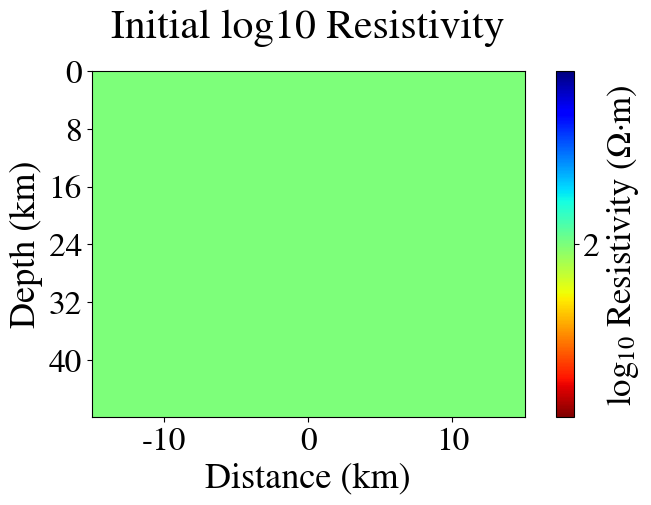

In [3]:
# 3) Inverter + synthetic data
inv = MT2DInverterWeightedCost(
    yn=torch.tensor(yn, dtype=torch.float64, device=device),
    zn=torch.tensor(zn, dtype=torch.float64, device=device),
    nza=nza,
    freqs=freqs,
    stations=stations,
    device=device,
    random_seed=123,
    te_weight=1.0,
    tm_weight=1.0,
    data_loss_scale=30,
)
inv.set_forward_operator()
inv.sig_true = sig_true
inv.create_synthetic_data(noise_level=0.04,
                        noise_type="gaussian",
                        )
inv.update_ot_w_d_per_point_from_noise(
    w_d_scale=[2.0, 1.0, 1.0, 1.0],  # [rhoxy, phsxy, rhoyx, phsyx]
    normalize="mean",)
inv.initialize_model(initial_sigma=0.01)
inv.plot_initial_model(clip_to_stations=True, ylim=[50, 0],synthetic_figwidth_scale=2.0)


In [4]:
# 4b) MSE 反演（同一静位移观测数据，重置初模）
inv.initialize_model(initial_sigma=0.01)
final_sigma_mse = inv.run_inversion(
    n_epochs=500,
    mode="mse",
    progress_interval=20,
    current_lambda=1,
    use_adaptive_lambda=True,
    lr=0.03,
    update_interval=10,
    norm_type="L2",
    alpha=0.5,
    use_depth_weights=True,
    rms_chi2_stop=1.05,
    profile_timing=False,
)
print("MSE inversion done")
print(final_sigma_mse.min().item(), final_sigma_mse.max().item())

✓ Model initialization complete: Uniform.
  - Air layer fixed: nza=10, air_sigma=1.00e-10 S/m
✓ Optimizer: AdamW, lr=0.03, weight_decay=0.0
✓ Optimizer: AdamW, lr=0.03, weight_decay=0.0
Epoch 1/500 [   0.2%]
  Elapsed: 0:00:02 | Remaining: ~0:12:52 | ETA: 16:07:39
  Epoch time: 1.55s | Avg: 1.55s
  Total: 3.6028e-01 | Data(mse): 3.6028e-01
  [Cost weights] w_s=1.000, w_f=1.000, w_d=tensor([[2.0000, 1.0001, 1.0000, 1.0000],
        [2.0000, 1.0001, 1.0000, 1.0000],
        [2.0000, 1.0001, 1.0000, 1.0000],
        ...,
        [2.0000, 1.0001, 1.0000, 1.0000],
        [2.0000, 1.0001, 1.0000, 1.0000],
        [2.0000, 1.0001, 1.0000, 1.0000]], device='cuda:0')
  Misfit(RMS χ²): 1.601 | Rough: 0.00e+00 | Lam: 1.0000000
  OT-distance(6D, view-only): 2.573657e+00
  GradNorms: |g_d|=nan | |λ·g_m|=nan
 [Auto-Lambda] Epoch 10: Adjusted 1.00e+00 -> 1.42e-01 (ratio=2.010e-02)
 [Auto-Lambda] Epoch 20: Adjusted 1.42e-01 -> 3.73e-02 (ratio=6.921e-02)
Epoch 21/500 [   4.2%]
  Elapsed: 0:00:31 | Rem

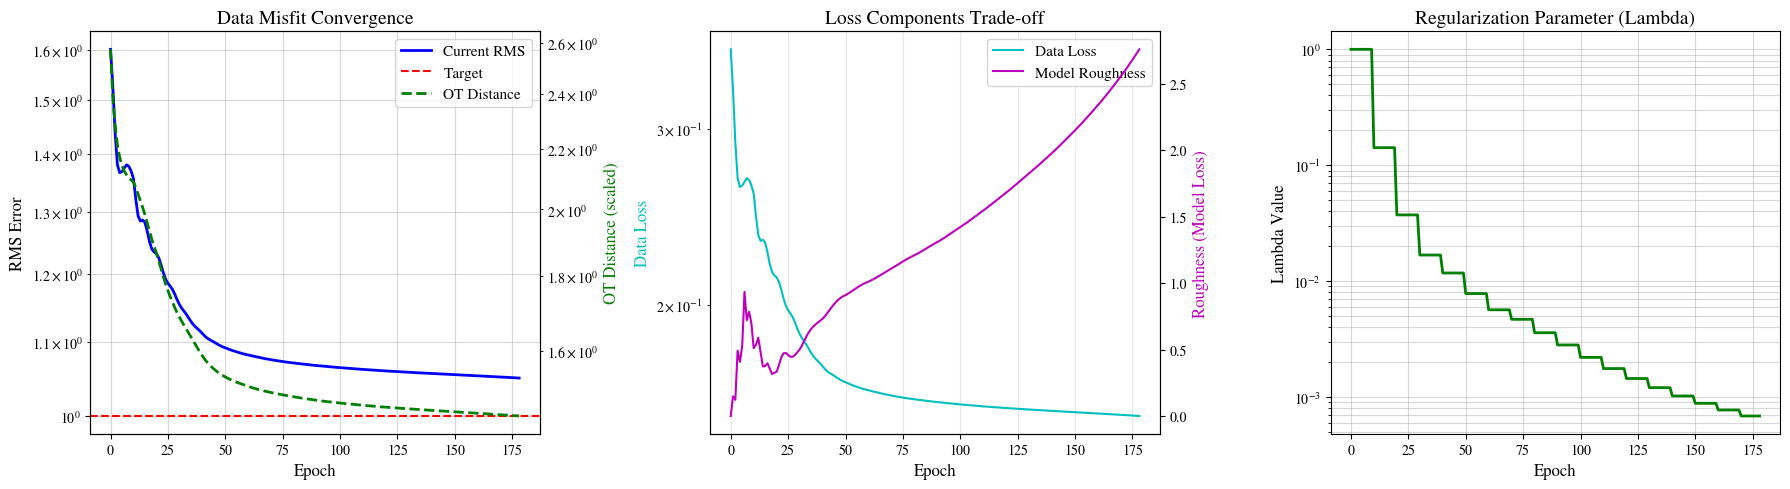

Model structural similarity (SSIM): 0.2982


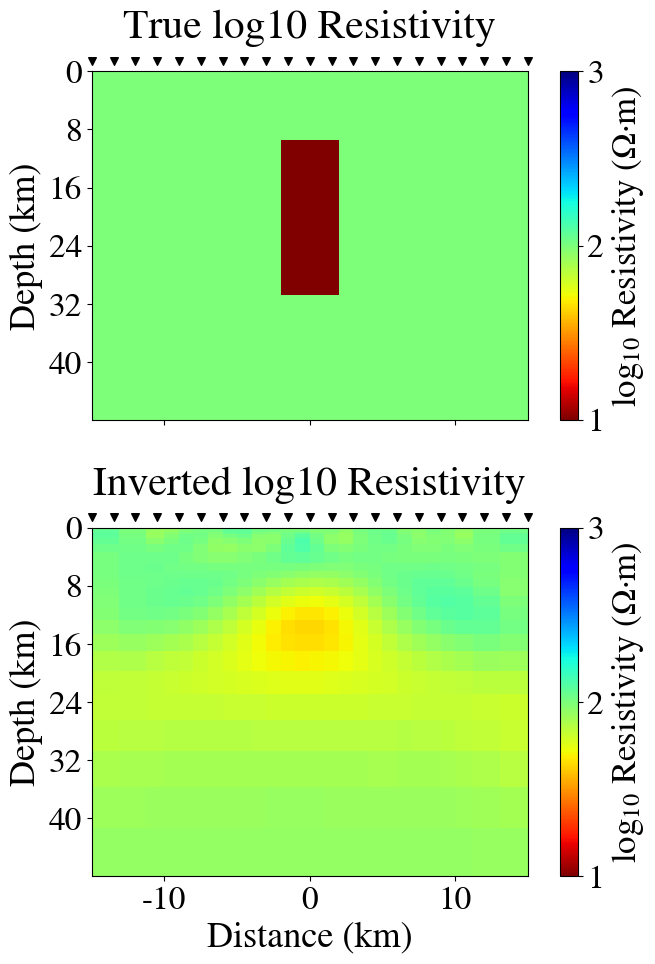

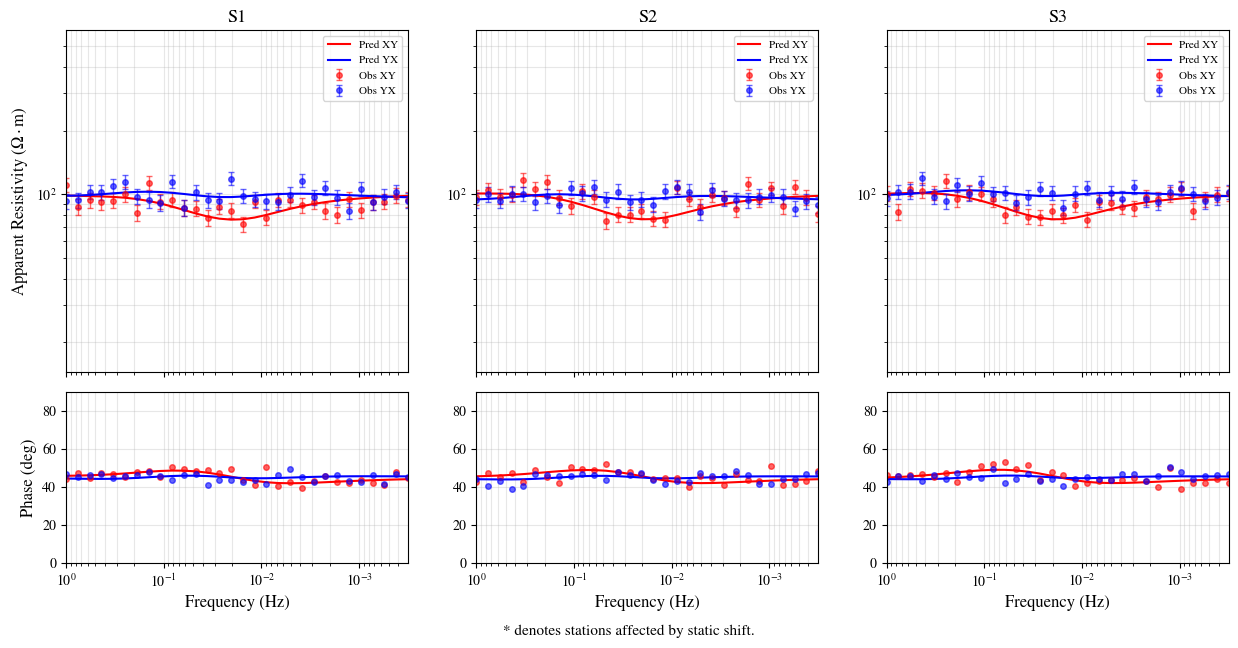

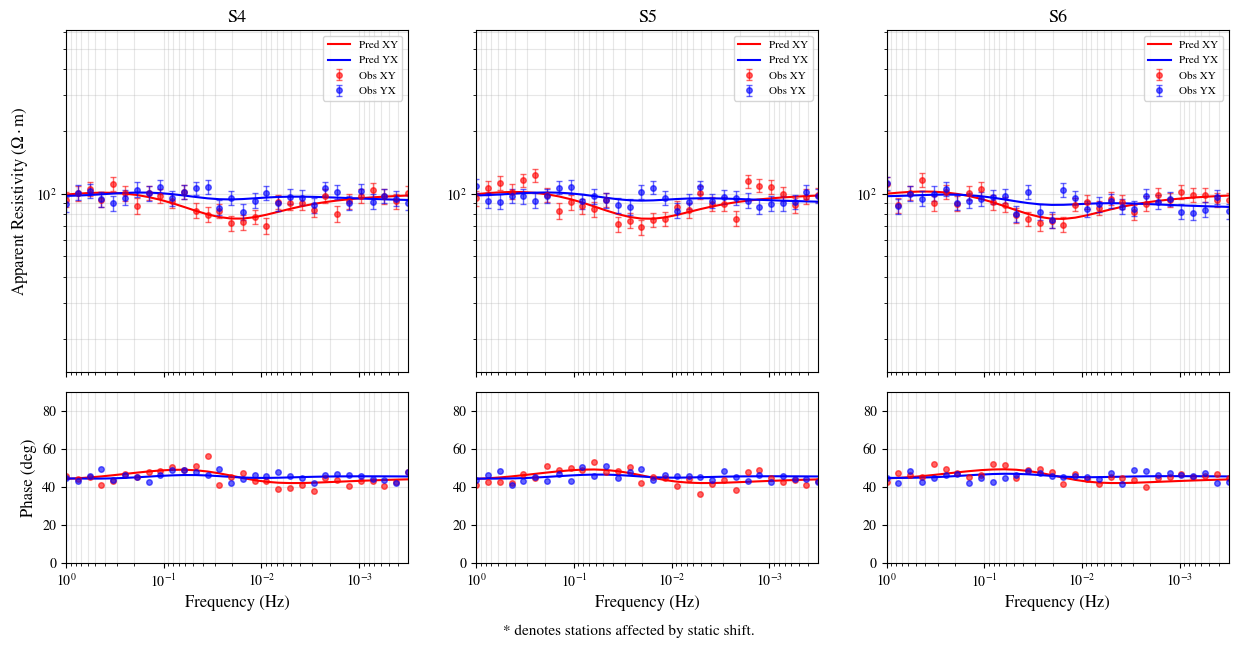

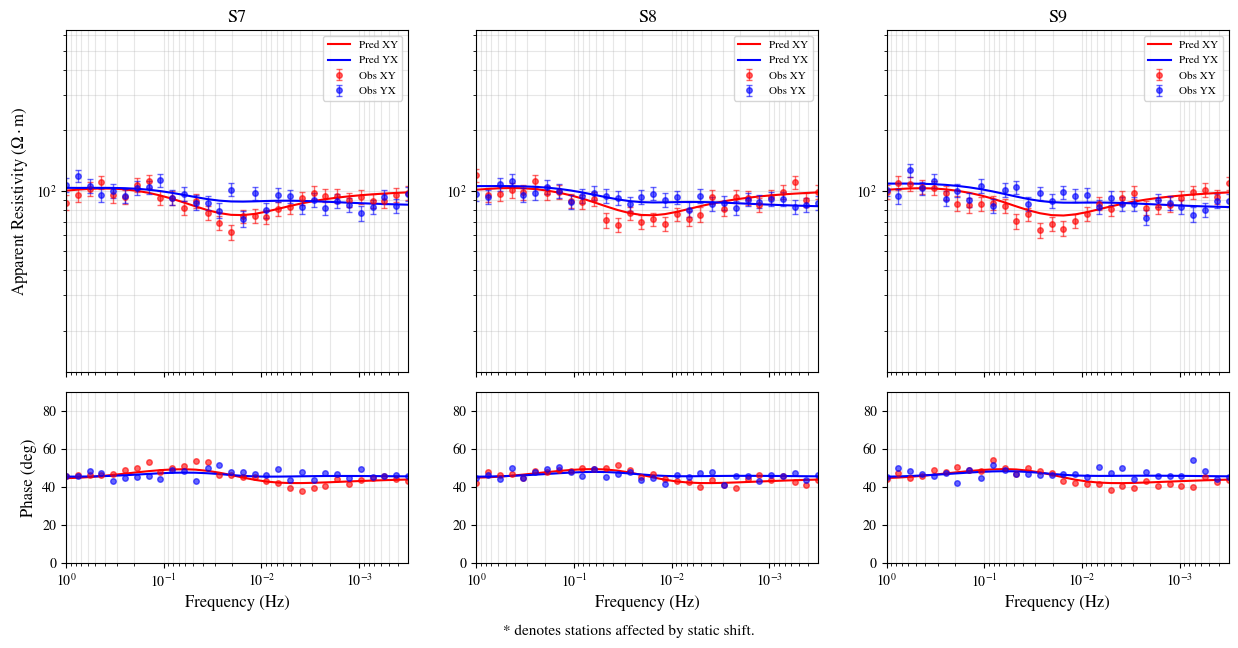

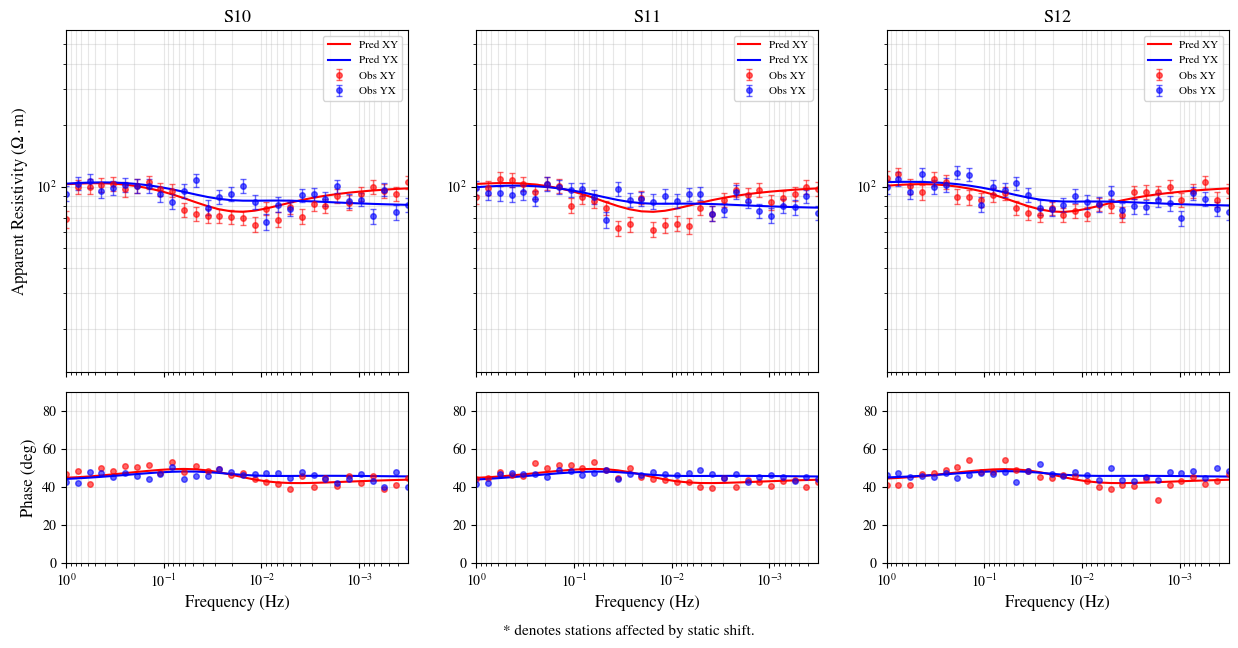

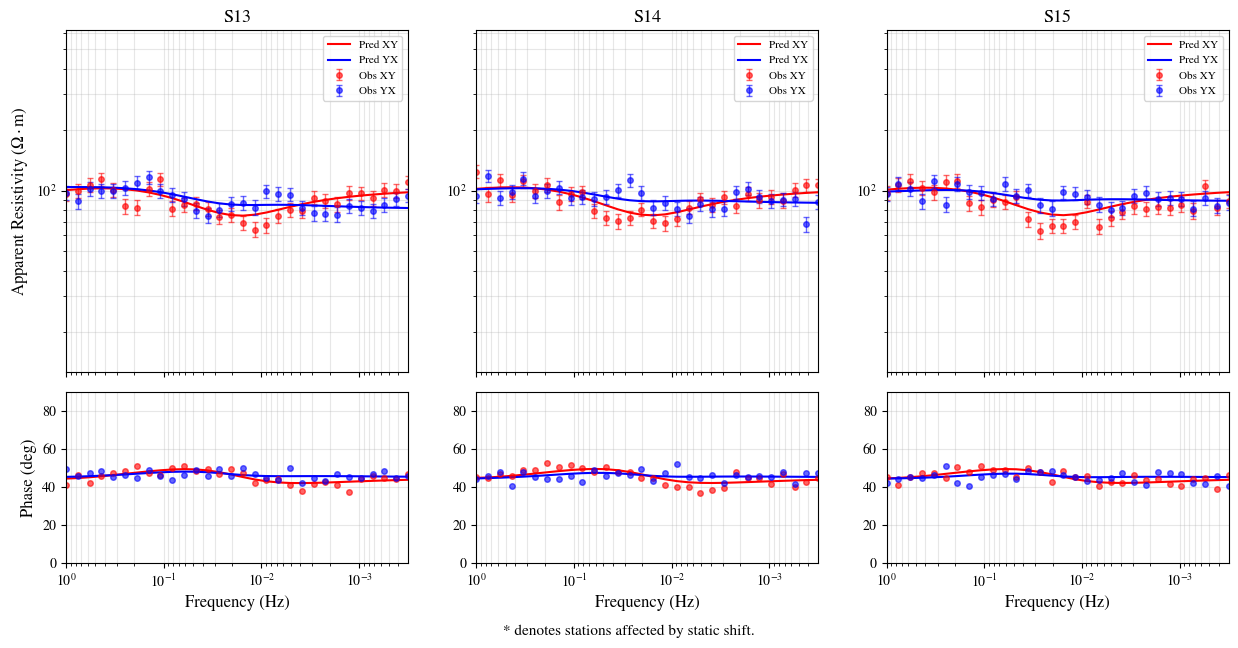

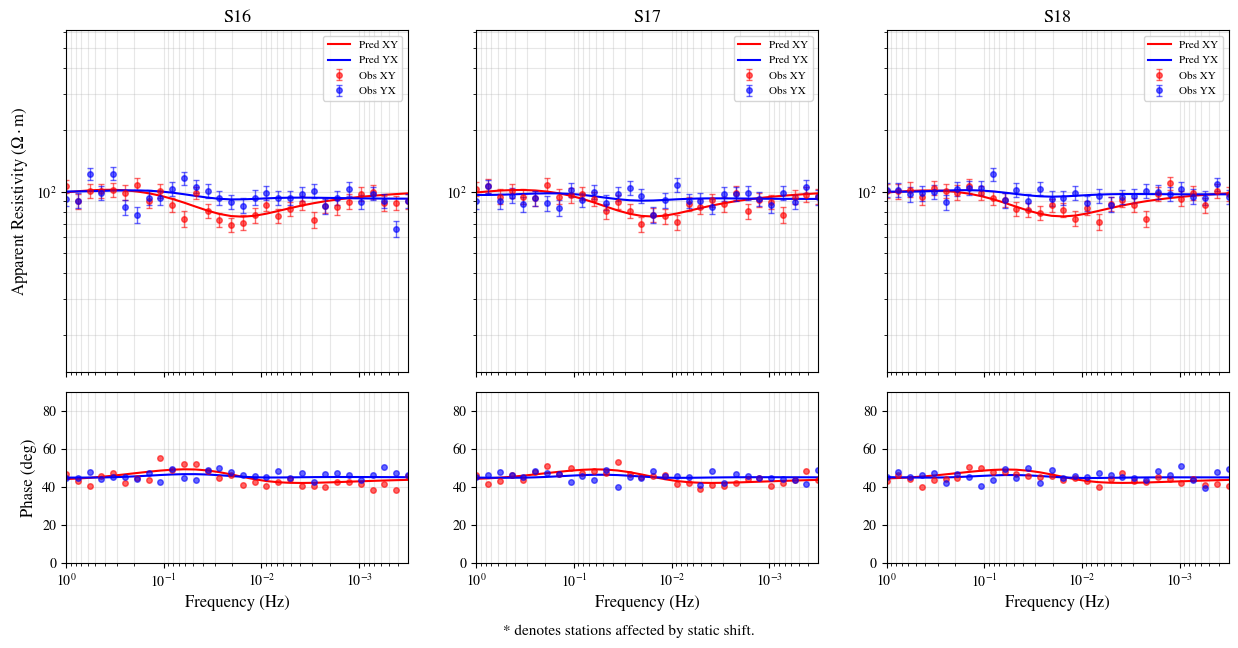

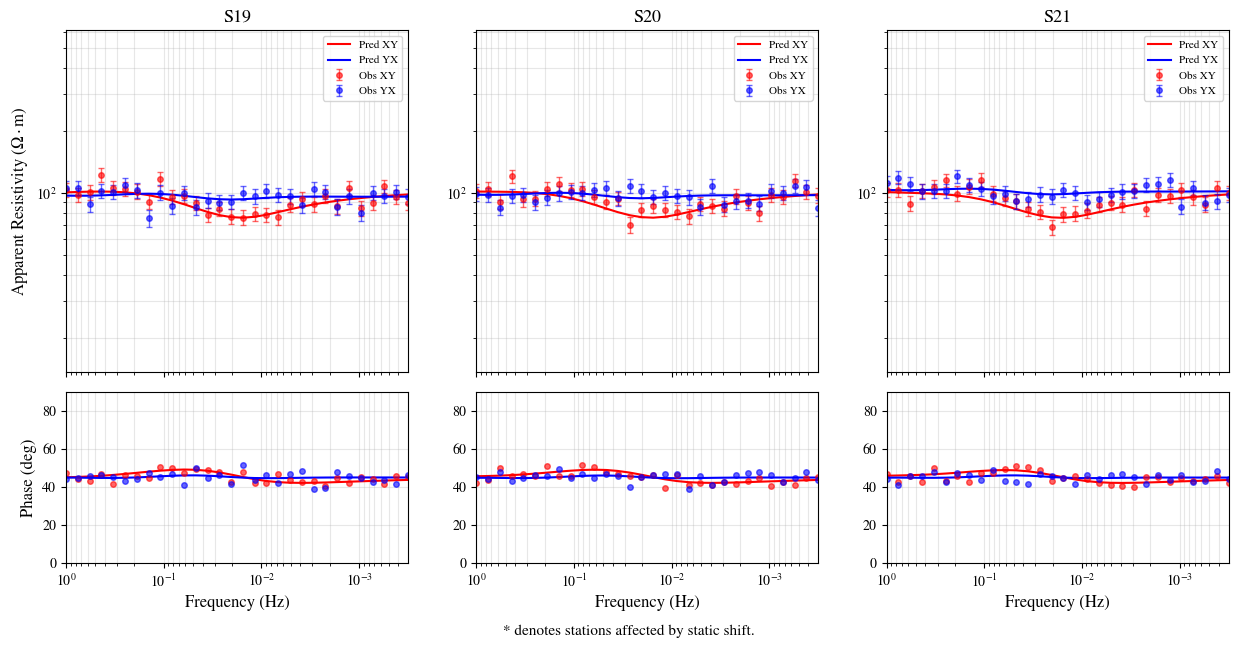

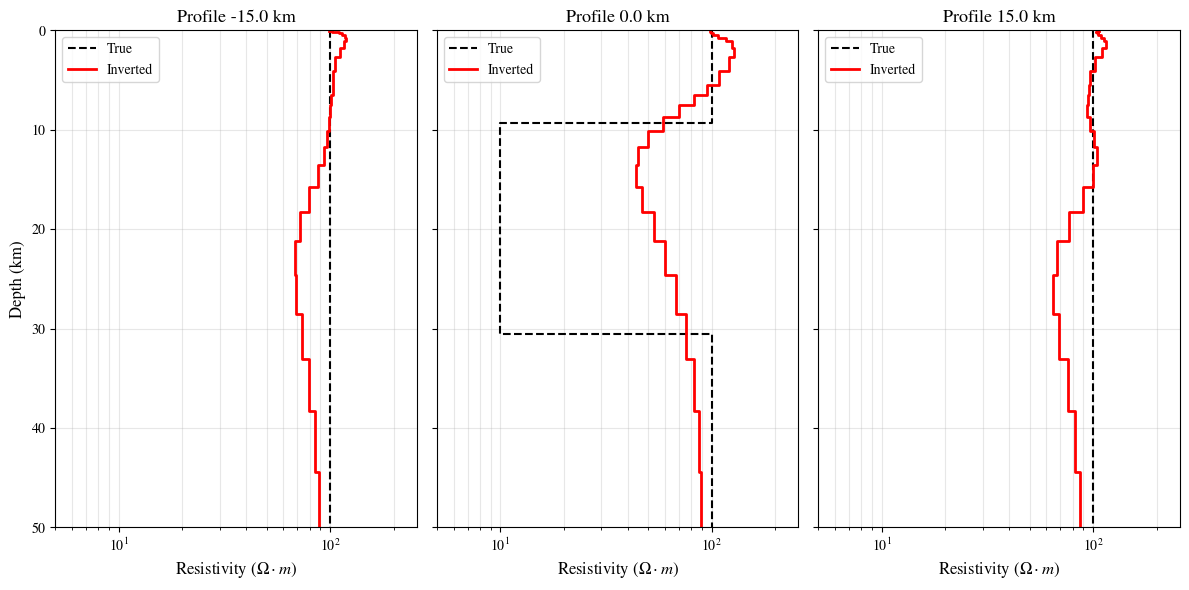

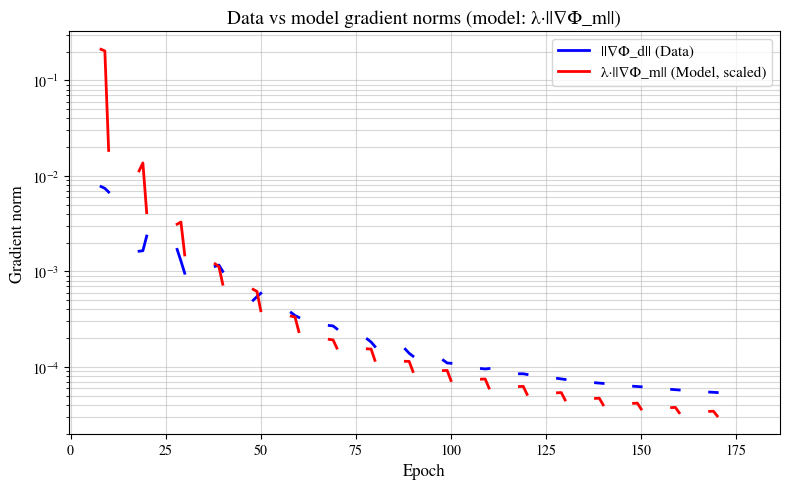

In [5]:
# 5b) MSE 结果绘图
inv.plot_loss_history()
inv.plot_model_comparison(
    cmap="jet_r",
    clip_to_stations=True,
    ylim=[50, 0],
    vmin=1,
    vmax=3,
    synthetic_figwidth_scale=2.0,
)
inv.plot_data_fitting()
inv.plot_1d_profiles(depth_limit_km=50)
inv.plot_gradient_history()

In [8]:
mse_run_dir = logger.save_from_inverter(inv, run_name="mse_0.04")
history_mse = list(inv.loss_history)
print(f"MSE run saved: {mse_run_dir}")


Saving results to: test_results/ccmm2d1/2026-08-10_16-39-56_mse_21_0.04
  ✓ summary.csv
  ✓ history.csv
  ✓ config.json
  ✓ timing.json
  ✓ meta.json
  ✓ final_model.npz
  ✓ static_shift.json
  ✓ apparent_resistivity.npz
Model structural similarity (SSIM): 0.2982
  ✓ model_comparison.png/.pdf
  ✓ initial_model.png/.pdf
  ✓ data_fitting: 7 plots saved to test_results/ccmm2d1/2026-08-10_16-39-56_mse_21_0.04/figures/data_fitting (21 stations)
  ✓ profiles_1d.png/.pdf
  ✓ Figures saved to test_results/ccmm2d1/2026-08-10_16-39-56_mse_21_0.04/figures

Results saved successfully!
  Location: test_results/ccmm2d1/2026-08-10_16-39-56_mse_21_0.04
  Final RMS χ²: 1.0499
  RMSE: 0.1539
  MAPE: 5.51%

MSE run saved: test_results/ccmm2d1/2026-08-10_16-39-56_mse_21_0.04
